# Matplotlib HW07

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

## Part 1: Identifying Physical Diffrences between Iris dataset.

In [3]:
# Load Iris Dataset
iris = load_iris()

In [4]:
# Compare physical properties of the species. 
# Create a scatter plot of sepal length vs sepal width, colored by species.
# Create a box plot to compare the distribution of petal widths across the three species.
# Create a Violin Plot to compare the distribution of sepal lengths across the three species.

### Scatter Plot

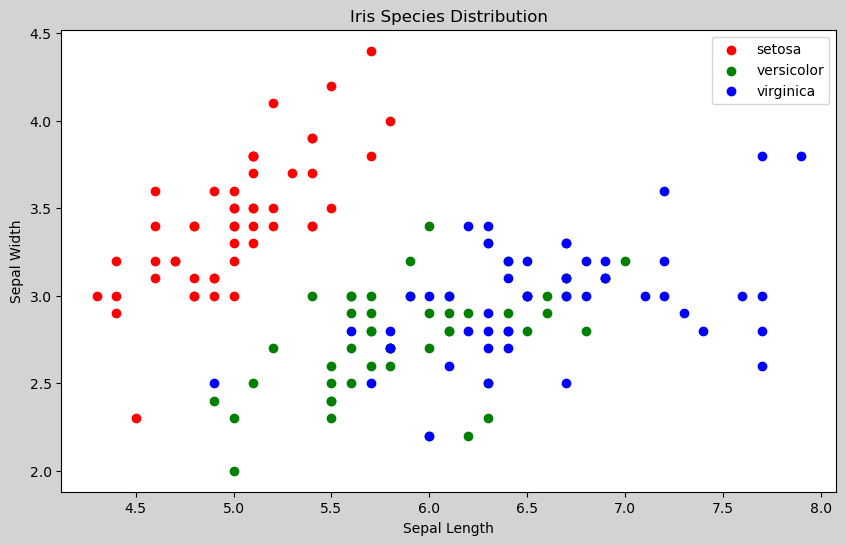

In [5]:
# Creating a scatter plot of sepal length vs sepal width, colored by species to see the distribution of the three species based on these two features.

custom_colors = ['red', 'green', 'blue'] # Used standard colors for the 3 species.
# Using this to change the colors from the default ones to enhance the visual appeal of the plot.

plt.figure(figsize=(10, 6), facecolor='lightgray')
for i in range(3):
    plt.scatter(iris.data[iris.target == i][:, 0], iris.data[iris.target == i][:, 1], label=iris.target_names[i], color=custom_colors[i])

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Species Distribution')
plt.legend()
plt.show()

* Within the scatter plot, we can observe that the setosa species (red) is very distinct from the versicolor (green) and virginica (blue) species, which overlap more. 
* This indicates that sepal length and width are effective features for distinguishing setosa from the other two species, while versicolor and virginica may require additional features for better separation.
* Another aspect is that the overlaping between versicolor and virginica suggests that these two species have similar sepal dimensions, which may lead to potential misclassification if only these features are used.
* Finally, the scatter plot visually confirms that the dataset can be used for classification tasks, due to the noticable clustoring of the species.

### Box Plot

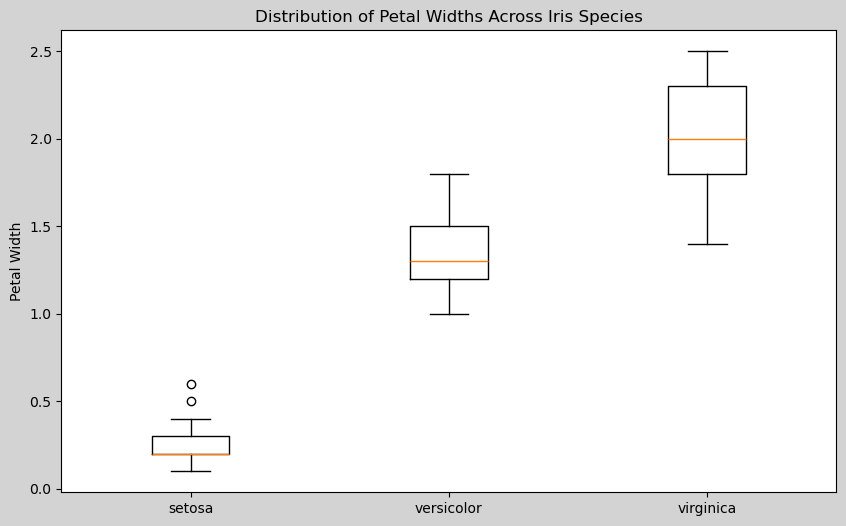

In [6]:
# Next is creating the box plot to compare the distribution of petal widths across the three species. This will help us understand how the petal widths vary among the different species.

plt.figure(figsize=(10, 6), facecolor='lightgray') # Setting the background color to light gray for better contrast with the box plot.
plt.boxplot([iris.data[iris.target == i][:, 3] for i in range(3)], tick_labels=iris.target_names)
plt.ylabel('Petal Width')
plt.title('Distribution of Petal Widths Across Iris Species')
plt.show()

* Setosa's distribution appears to be far less with no noticable overlap with the other species similar to the scatter plot. It also contains 2 outliners within its set. The species also has its median exactly on the lower quartile (Q1) which could be an indication that the values of at least 50% are equal or less than Q1 (indication of heavy clustering).
* With the overlap with Versicolor and Virginica with their upper and lower whiskers respectfully showing that some samples could be of the same size as one another. Which lines up with what was disscussed in the scatter plot. This could lead to misidentifcation in machine learning models reguarding the petal width.
* Virginica has a large IQR from is size, indicating more variety in measurements. The whiskers also extend more (espechually in its lower one) indicating wider total range of values.

### Violin Plot

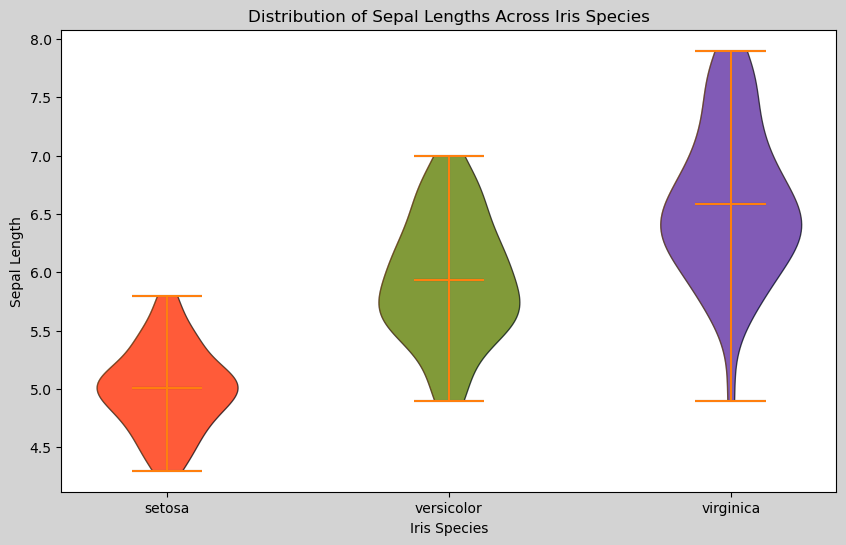

In [7]:
# Finally creating a violin plot to compare the distribution of sepal lengths across the three species. This will give us a visual representation of the density of sepal lengths for each species.

plt.figure(figsize=(10, 6), facecolor='lightgray')

vplot = plt.violinplot([iris.data[iris.target == i][:, 0] for i in range(3)], positions=range(3), showmeans=True)
colors = ['red', 'green', 'blue']

for i, body in enumerate(vplot['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.7)

vplot['cmeans'].set_color('black')


plt.violinplot([iris.data[iris.target == i][:, 0] for i in range(3)], positions=range(3), showmeans=True)
plt.xlabel('Iris Species')
plt.ylabel('Sepal Length')
plt.title('Distribution of Sepal Lengths Across Iris Species')
plt.xticks(range(3), iris.target_names)
plt.show()

* Noticed features from the boxplot (width) can be notice even more with the violen plot even though we are looking at length (the setosa's is a evenly spread and focused within the median, then both versicolor and virginica do show peaks below the median which is can be a repersentation of the there long whiskers).
* The Virgincia even now show signs of a downward skewness since a few plants have very significantly shorter sepal lengths.
* There is overlap across each species but more noticablly with Versicolor and Virginica. While having averages differ there species could be hard to identify with length alone. A machine-learning model could have a tough time correctly identifying their groups.
* All 3 species violin graph appear to be unimodal (one main peak/common value).

## Part 2: Analysing Conclusions on Visualization on Customer Loans

In [8]:
# Load dataset's csv file.
import pandas as pd
loans = pd.read_csv('C:/Users/13176/Desktop/2026 Classes/Information Infrastructure II/HW/HW07/LoanDataset.csv')

In [9]:
loans.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


### Bar Chart

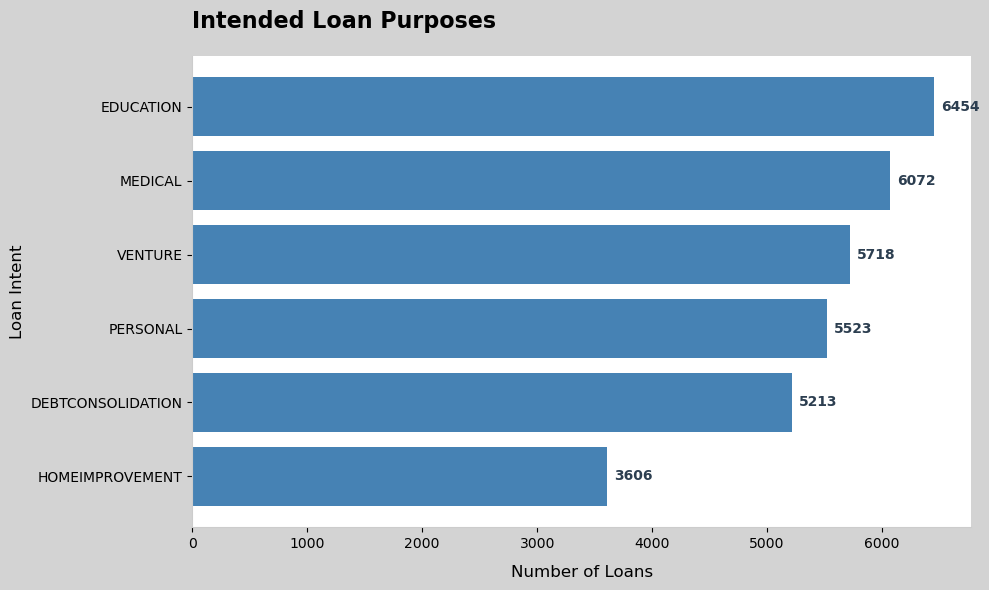

In [38]:
# Creating a bar chart showing the distribution of loan purposes to understand the most common reasons for taking out a loan.
loan_purpose_counts = loans['loan_intent'].value_counts().sort_values(ascending=True) # Sorting the values in ascending order for better visualization in the horizontal bar chart.
plt.figure(figsize=(10, 6), facecolor='lightgray')
bars = plt.barh(loan_purpose_counts.index, loan_purpose_counts.values, color='steelblue')

plt.bar_label(bars, padding=5, color='#2c3e50', fontweight='bold')

plt.title('Intended Loan Purposes', fontsize=16, pad=20, loc='left', fontweight='bold')
plt.xlabel('Number of Loans', fontsize=12, labelpad=10)
plt.ylabel('Loan Intent', fontsize=12)

# Remove the top and right borders (spines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')

# 5. Final polish
plt.tight_layout()
plt.show()

* Education has the most loans borrowed, going over 6,000 loans. Showing that the bank/industry has strong demographic towards students or young professionals.
* Since both education, and medical are the top 2 then the main expenses are towards 'unavoidable'/'essential' expenses (necessity).
* Home improvements are the lowest group (under 4,000). Since its connected to a asset theses kinds of loans are quite safe because of that connecting.
* A majority of the groups are very close in volume showing that the group has a diverse portfolio and not focused on single section.

### Scatter Plot

In [ ]:
# Removed the currency symbols and commas from the 'loan_amnt' column and converted it to a numeric type (float) for analysis.
loans['loan_amnt'] = loans['loan_amnt'].replace('[\£,]', '', regex=True).astype(float)

# Verify the change by checking the dtype (should be float64)
print(loans['loan_amnt'].dtype)

float64


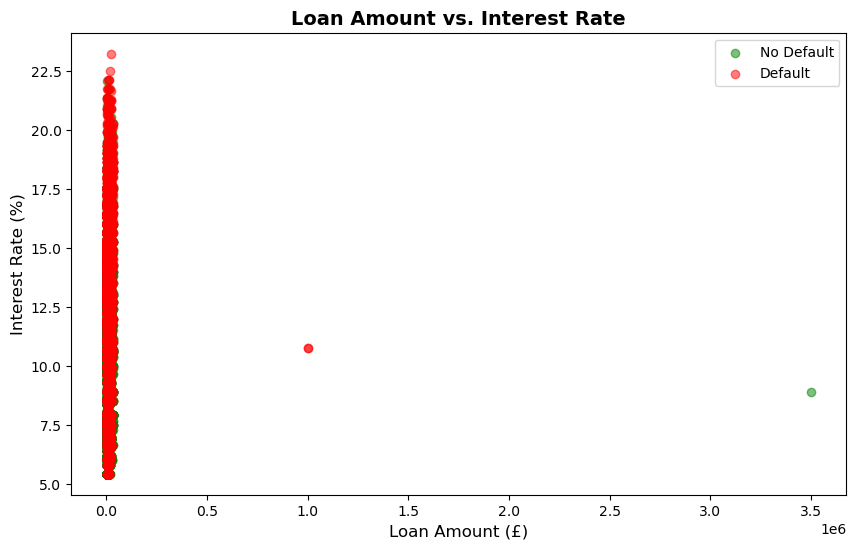

In [26]:
# Creating a scatter plot comparing loan amounts to interest rates, colored by loan status to see if there are any patterns in how loan amounts and interest rates relate to the likelihood of a loan being fully paid or charged off.
plt.figure(figsize=(10, 6))

# Separate data by status (e.g., DEFAULT vs NO DEFAULT)
defaults = loans[loans['Current_loan_status'] == 'DEFAULT']
no_defaults = loans[loans['Current_loan_status'] == 'NO DEFAULT']

# Plot each group
plt.scatter(no_defaults['loan_amnt'], no_defaults['loan_int_rate'], 
            alpha=0.5, label='No Default', color='green')
plt.scatter(defaults['loan_amnt'], defaults['loan_int_rate'], 
            alpha=0.5, label='Default', color='red')

plt.title('Loan Amount vs. Interest Rate', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount (£)', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.legend()
plt.show()

* There are 2 outliers that the scatter plot shows (First at 1.0 = 1,000,000, and 2nd at 3,500,000). This is causing a squish affect to occur on the other loans creating this wall close to zero becacuse of there values. So I then will filter out the loan amount to avoid the outliners.

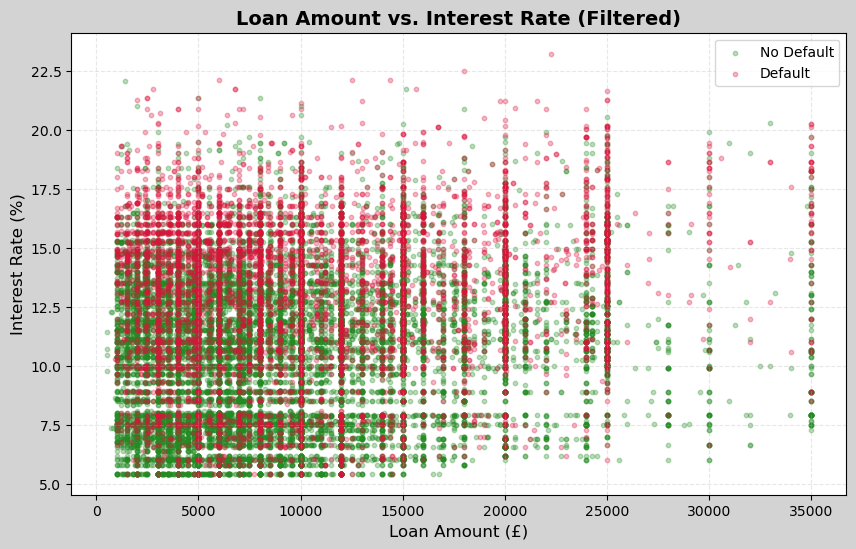

In [32]:
# Create the scatter plot again but not include the outliers at 1 mil pound and above.
plt.figure(figsize=(10, 6), facecolor='lightgray')
# Filter out outliers (e.g., loans above £1 million)    
filtered_loans = loans[loans['loan_amnt'] < 1_000_000] # Showing values below 1 million to focus on the majority of the data and improve the readability of the plot.
# Separate data by status (e.g., DEFAULT vs NO DEFAULT) 
defaults = filtered_loans[filtered_loans['Current_loan_status'] == 'DEFAULT']
no_defaults = filtered_loans[filtered_loans['Current_loan_status'] == 'NO DEFAULT']
# Plot each group

# s = 10, and alpha = 0.3 to make the points smaller and more transparent, which can help reduce overplotting and make the plot easier to read.
plt.scatter(no_defaults['loan_amnt'], no_defaults['loan_int_rate'], s=10,
            alpha=0.3, label='No Default', color='forestgreen')
plt.scatter(defaults['loan_amnt'], defaults['loan_int_rate'], s=10,
            alpha=0.3, label='Default', color='crimson')
plt.title('Loan Amount vs. Interest Rate (Filtered)', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount (£)', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

* Majority of the loans below 7.5% intrest rate are more safe for lenders.
* Then everything roughtly above 15% intrest rate is highly densed with red dots, indicating that is a very strong predictor of defaulting than the total amount that is borrowed.
* The vertical lines of plots are due to borrowers requesting rounded numbers since that is what human behaivor often leads at.

### Pie Plot

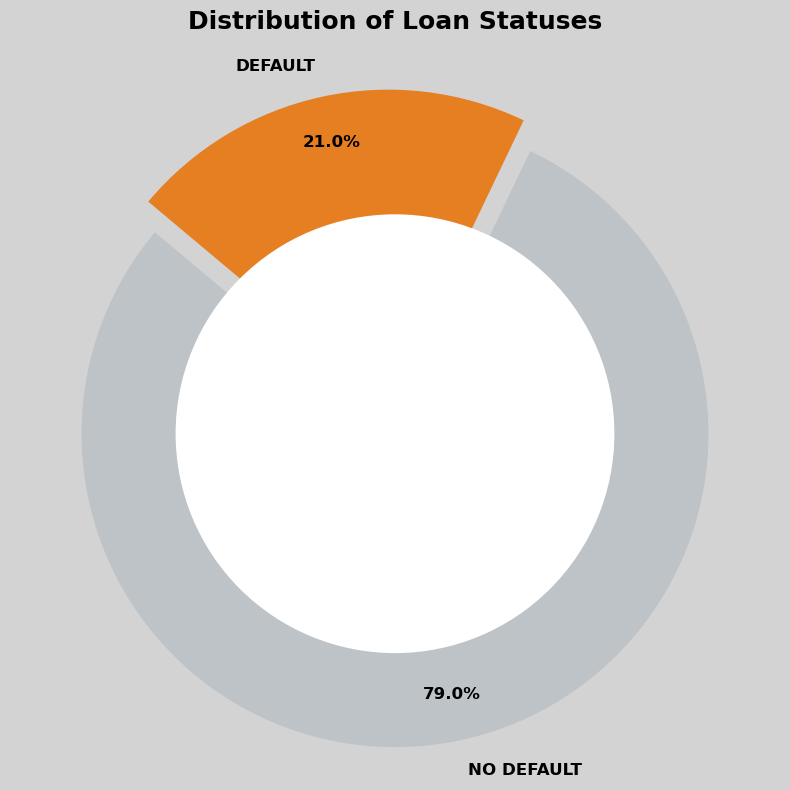

In [41]:
# Create a pie chart to show the distribution of loan statuses (e.g., defaulted vs. paid).
loan_status_counts = loans['Current_loan_status'].value_counts()

colors = ['#bdc3c7', '#e67e22'] 
explode = (0, 0.1)  # Slightly pop out the "Default" slice for emphasis.
plt.figure(figsize=(8, 8), facecolor='lightgray')

patches, texts, autotects = plt.pie(
    loan_status_counts.values, 
    labels=loan_status_counts.index, 
    autopct='%1.1f%%', 
    startangle=140,    # Rotates the chart for better visual balance
    colors=colors, 
    explode=explode,
    pctdistance=0.85,  # Moves percentages toward the edge of the slice
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)


centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


plt.title('Distribution of Loan Statuses', fontsize=18, fontweight='bold', pad=20)

plt.axis('equal') 
plt.tight_layout()
plt.show()

* There is roughly a 4:1 ratio showing that for every 4 healthy loans (No Default), there is about 1 borrower that fails their pay (Default).
* The 21% is quite the average for a bank (unknow where dataset originates) that normally aims for '>5%'. So either the leading enviorment or the data set is to study credit risk (uploaded to be used for analysis or machine learning tasks).
* The 21% is a very high financial drain towards the group. The intrest might be large enough to cover the loss but a deeper dive show be look into to confirm.